# Taller de Modelado de Series Temporales: Temperatura de la Superficie Terrestre (2000–2025)

## Contexto
La base de datos seleccionada corresponde a la **temperatura de la superficie terrestre registrada cada hora entre los años 2000 y 2025**.  
Este conjunto de datos es especialmente valioso porque:  
- Tiene **alta granularidad** (registros horarios).  
- Cubre un **periodo largo de 25 años**.  
- Permite observar **patrones estacionales** en múltiples escalas: diaria, semanal, mensual y anual.  

## Objetivo del taller
Comparar tres enfoques de pronóstico en términos de capacidad predictiva:  
1. **SARIMAX**: modelo estadístico que captura tendencia y estacionalidad mediante parámetros autorregresivos y de medias móviles.  
2. **Prophet**: modelo basado en descomposición aditiva, diseñado para manejar tendencias y múltiples estacionalidades.  
3. **LSTM**: red neuronal recurrente capaz de aprender patrones complejos en secuencias temporales densas.  

## Metodología
1. **División de datos**: separar la serie en entrenamiento y prueba (ejemplo: 80% entrenamiento, 20% prueba).  
2. **Entrenamiento de modelos**: ajustar SARIMAX, Prophet y LSTM sobre el conjunto de entrenamiento.  
3. **Pronóstico en el conjunto de prueba**: generar predicciones y compararlas con los valores reales.  
4. **Evaluación con métricas estadísticas**:  
   - RMSE (Root Mean Squared Error)  
   - MAE (Mean Absolute Error)  
   - MAPE (Mean Absolute Percentage Error)  
5. **Visualización**: graficar la serie real junto con los pronósticos de cada modelo.  
6. **Comparación y conclusión**: determinar cuál modelo ofrece el mejor rendimiento en el conjunto de prueba.  

## Entrega en cinco minutos
La explicación debe cubrir:  
- La **serie temporal** (temperatura horaria y sus patrones estacionales).  
- La **salida de cada modelo** en términos de ajuste y pronóstico.  
- La **comparación de métricas** y la conclusión sobre cuál modelo predice mejor.  

## Resultado esperado
Un cuaderno Jupyter reproducible que muestre:  
- La serie temporal y sus estacionalidades.  
- Los pronósticos generados por SARIMAX, Prophet y LSTM.  
- Una tabla de métricas comparativas.  
- Una conclusión clara sobre el modelo más adecuado para este caso.  

In [1]:
# vamos a conocer la data
import pandas as pd

df = pd.read_csv('./data.csv')
df.head()

,valid_time,skt,latitude,longitude
0,2000-01-01 00:00:00,299.30040,10.5,-75.5
1,2000-01-01 01:00:00,299.15457,10.5,-75.5
2,2000-01-01 02:00:00,298.92023,10.5,-75.5
3,2000-01-01 03:00:00,298.88373,10.5,-75.5
4,2000-01-01 04:00:00,298.76154,10.5,-75.5


In [3]:
# la columna 'valid_time' esta en fecha y hora. para el grafico vamos a tener en cuenta solo la fecha
# no vamos a modificar la base original sino que vamos a crear una nueva columna con la fecha solamente
df['date'] = pd.to_datetime(df['valid_time']).dt.date
df.head()

,valid_time,skt,latitude,longitude,date
0,2000-01-01 00:00:00,299.30040,10.5,-75.5,2000-01-01
1,2000-01-01 01:00:00,299.15457,10.5,-75.5,2000-01-01
2,2000-01-01 02:00:00,298.92023,10.5,-75.5,2000-01-01
3,2000-01-01 03:00:00,298.88373,10.5,-75.5,2000-01-01
4,2000-01-01 04:00:00,298.76154,10.5,-75.5,2000-01-01


In [4]:
# ahora tambien vamos a eliminar las columnas 'latitude' y 'longitude' ya que no las vamos a usar para el grafico
df = df.drop(columns=['latitude', 'longitude'])
df.head()

,valid_time,skt,date
0,2000-01-01 00:00:00,299.30040,2000-01-01
1,2000-01-01 01:00:00,299.15457,2000-01-01
2,2000-01-01 02:00:00,298.92023,2000-01-01
3,2000-01-01 03:00:00,298.88373,2000-01-01
4,2000-01-01 04:00:00,298.76154,2000-01-01


In [13]:
# cantidad de registros
len(df)

227928

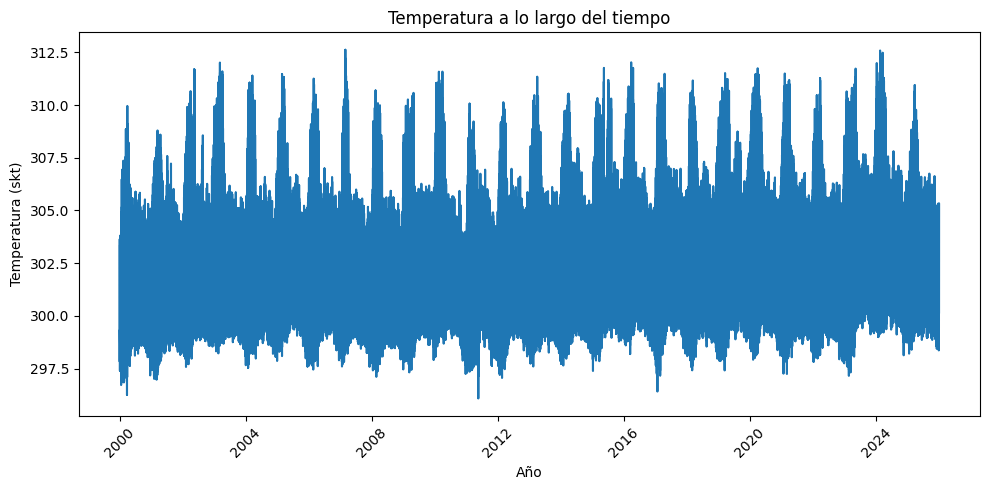

In [9]:
# bien ahora graficamos usando años en el eje x 
# eje y seria la columna 'skt'
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(df['date'], df['skt'])
plt.xlabel('Año')
plt.ylabel('Temperatura (skt)')
plt.title('Temperatura a lo largo del tiempo')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

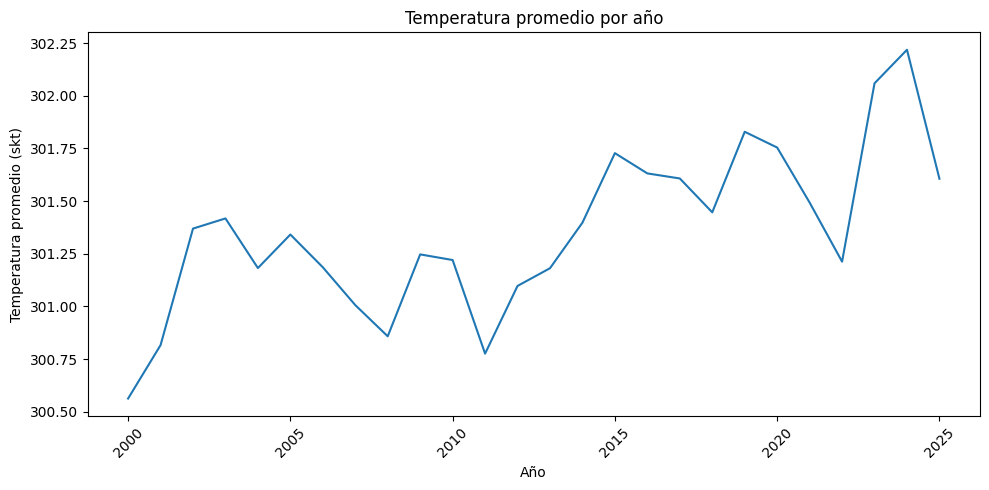

In [10]:
# vamos a hacer un promedio por año para suavizar la serie y ver mejor la tendencia
# que solo sea para mejorar el grafico no cambianos nada en la base original
df['year'] = pd.to_datetime(df['date']).dt.year
df_yearly = df.groupby('year')['skt'].mean().reset_index()
df_yearly.head()

plt.figure(figsize=(10, 5))
plt.plot(df_yearly['year'], df_yearly['skt'])
plt.xlabel('Año')
plt.ylabel('Temperatura promedio (skt)')
plt.title('Temperatura promedio por año')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
# vamos a intentar conocer los datos
df.describe()

,skt,year
count,227928.000000,227928.000000
mean,301.355674,2012.499631
std,2.452002,7.500410
min,296.086000,2000.000000
25%,299.592553,2006.000000
50%,300.501180,2012.000000
75%,302.724850,2019.000000
max,312.622560,2025.000000


In [16]:
# valores nulos?
df.isnull().sum()

valid_time    0
skt           0
date          0
year          0
dtype: int64

In [12]:
# vamos a divir mis datos entre entrenamiento y prueba
# usaremos los 20 primeros años para entrenamiento y los ultimos 5 años para prueba
train = df_yearly[df_yearly['year'] <= 2020]
test = df_yearly[df_yearly['year'] > 2020]

### SARIMAX 
empezamos por el modelo SARIMAX, que es un modelo estadístico que captura la tendencia y la estacionalidad de la serie temporal mediante parámetros autorregresivos y de medias móviles.